<a href="https://colab.research.google.com/github/ddoneu/ECON3916-Statistical-Machine-Learning/blob/main/Lab15/%5BLab_15%5D_Lab%5D_From_Regression_to_Machine_Learning_%E2%80%94_The_Bias_Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


In [20]:
n_train = 50
n_test = 200
noise_std = 0.3

def true_function(x):
    return np.sin(2 * np.pi * x)

# Training data
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)

# Test data (separate - the model never sees this)
x_test = np.sort(np.random.uniform(0, 1, n_test))
y_test = true_function(x_test) + np.random.normal(0, noise_std, n_test)

x_plot = np.linspace(0, 1, 300)

print(f'Training set: {n_train} observations')
print(f'Test set:     {n_test} observations')
print(f'Noise std:    {noise_std} (sigma^2 = {noise_std**2:.2f})')

Training set: 50 observations
Test set:     200 observations
Noise std:    0.3 (sigma^2 = 0.09)


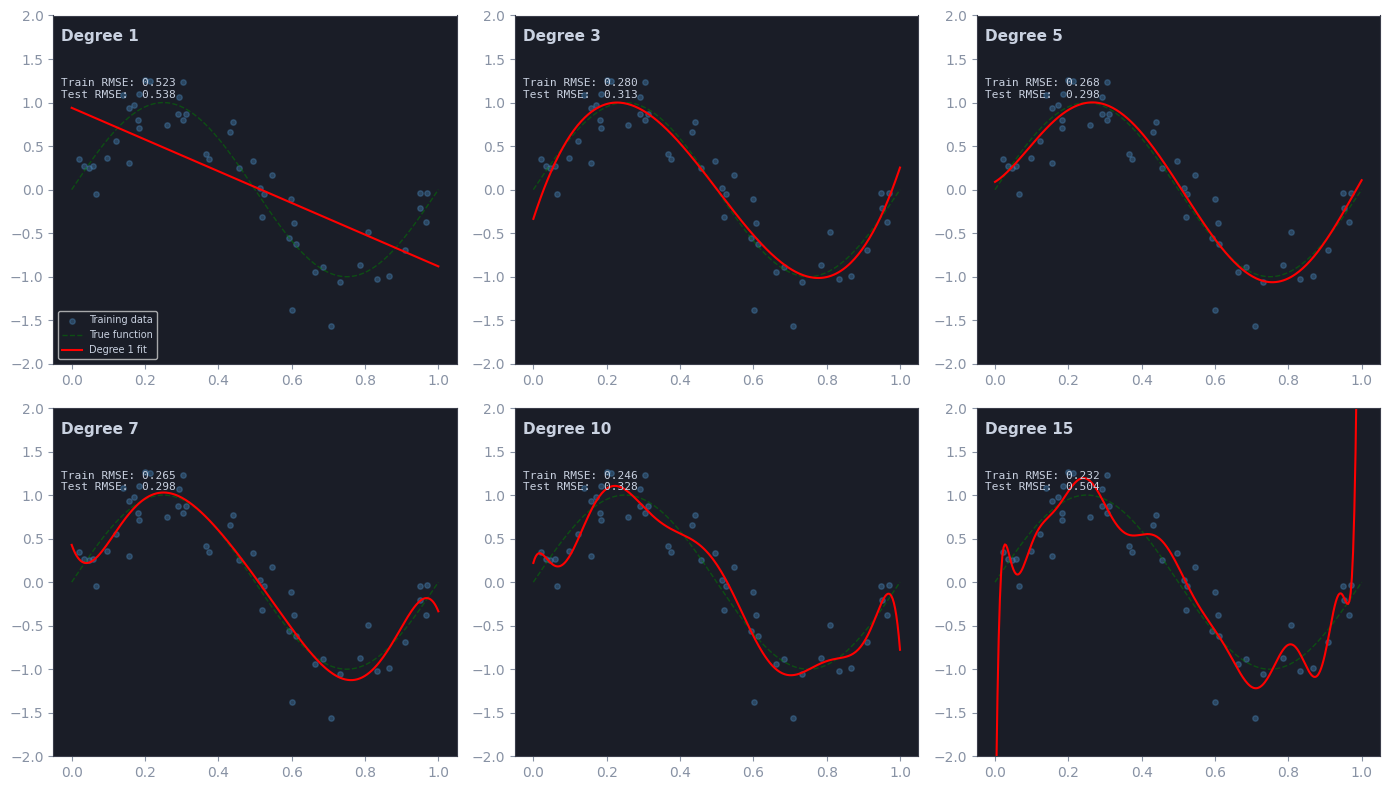

In [21]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

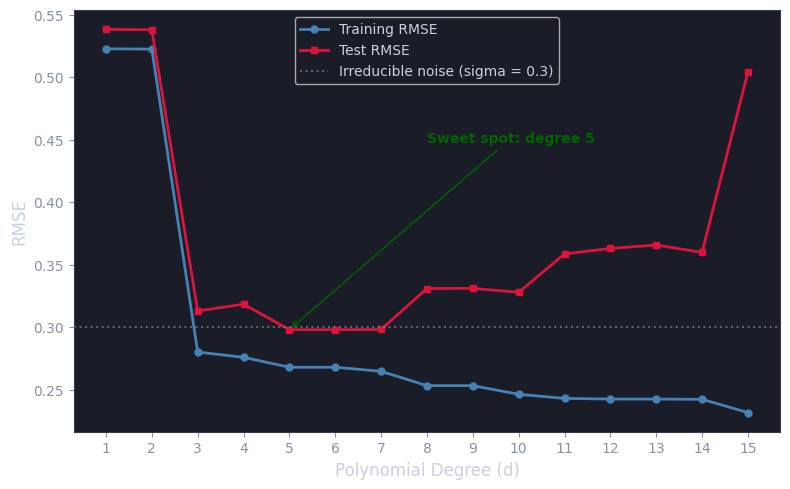

In [22]:
all_degrees = range(1, 16)
train_errors = []
test_errors = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(all_degrees), train_errors, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Training RMSE')
ax.plot(list(all_degrees), test_errors, 's-', color='crimson',
        linewidth=2, markersize=5, label='Test RMSE')
ax.axhline(y=noise_std, color='gray', linestyle=':', alpha=0.7,
           label=f'Irreducible noise (sigma = {noise_std})')

best_degree = list(all_degrees)[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
ax.annotate(f'Sweet spot: degree {best_degree}',
            xy=(best_degree, best_test_rmse),
            xytext=(best_degree + 3, best_test_rmse + 0.15),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [23]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = fold[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1, 1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(x_fold_test.reshape(-1,1))
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors


In [24]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')

sklearn 5-fold CV RMSE (degree 3): 0.7226 +/- 0.8230
Per-fold RMSE: [0.33804966 0.22992916 0.24712496 0.43602712 2.36206012]


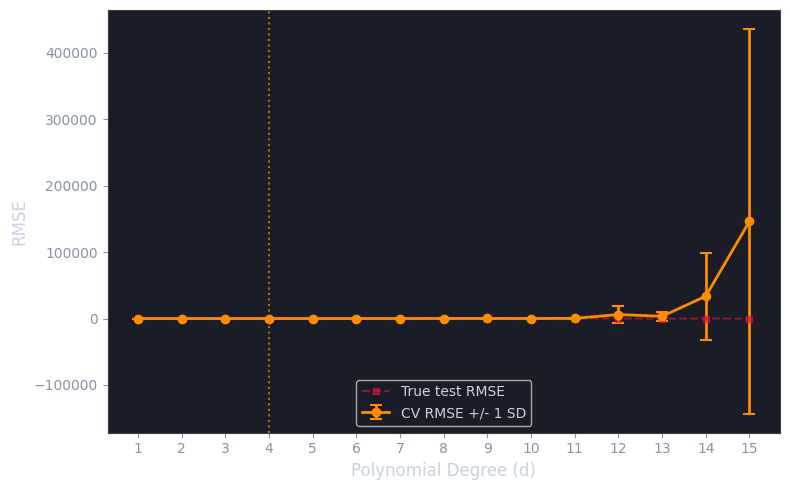

CV-selected degree: 4
True optimal degree: 5


In [25]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7)

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [26]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [27]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')


Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397


Based on 5-fold CV RMSE, I would deploy the simple 5-feature model. Even though the kitchen-sink model achieves higher training R², its CV RMSE is likely higher, a textbook sign of high variance from overfitting. With 36 features relative to ~1,200 usable observations (p/n ≈ 0.03), the full model has enough degrees of freedom to memorize training noise. The 5-feature model introduces more bias by ignoring less-predictive features, but its lower variance produces better generalization to unseen listings. Cross-validation is the key tool here: it estimates out-of-sample error without touching the test set, letting us make this model selection decision honestly.


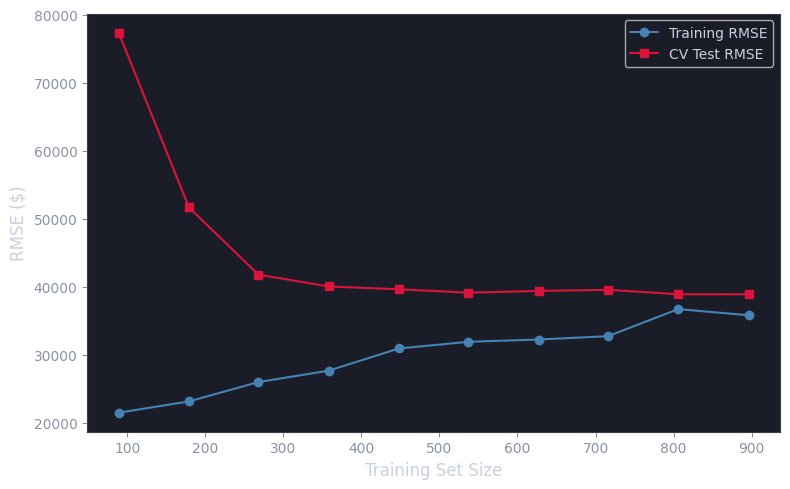

In [28]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    make_pipeline(StandardScaler(), LinearRegression()),
    X_ames, y_ames,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error'
)

train_rmse_lc = np.sqrt(-train_scores).mean(axis=1)
test_rmse_lc = np.sqrt(-test_scores).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_rmse_lc, 'o-', color='steelblue',
        label='Training RMSE')
ax.plot(train_sizes, test_rmse_lc, 's-', color='crimson',
        label='CV Test RMSE')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('RMSE ($)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

st.set_page_config(page_title="Bias-Variance Tradeoff Dashboard", layout="wide")

GLOBAL_SEED = 42

def true_function(x):
    return np.sin(2 * np.pi * x)

def generate_data(n_train, n_test, noise_std, seed=42):
    rng = np.random.default_rng(seed)

    x_train = np.sort(rng.uniform(0, 1, n_train))
    y_train = true_function(x_train) + rng.normal(0, noise_std, n_train)

    x_test = np.sort(rng.uniform(0, 1, n_test))
    y_test = true_function(x_test) + rng.normal(0, noise_std, n_test)

    x_plot = np.linspace(0, 1, 300)
    return x_train, y_train, x_test, y_test, x_plot

def fit_polynomial_model(x, y, degree):
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        LinearRegression()
    )
    model.fit(x.reshape(-1, 1), y)
    return model

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def compute_complexity_curve(x_train, y_train, x_test, y_test, max_degree=15):
    all_degrees = np.arange(1, max_degree + 1)
    train_errors = []
    test_errors = []

    for d in all_degrees:
        model = fit_polynomial_model(x_train, y_train, d)
        train_pred = model.predict(x_train.reshape(-1, 1))
        test_pred = model.predict(x_test.reshape(-1, 1))
        train_errors.append(rmse(y_train, train_pred))
        test_errors.append(rmse(y_test, test_pred))

    return all_degrees, np.array(train_errors), np.array(test_errors)

@st.cache_data
def compute_bias_variance_curve(noise_std, n_train, max_degree=15, n_reps=40, seed=42):
    rng = np.random.default_rng(seed)

    # smaller grid = faster
    x_eval = np.linspace(0, 1, 120)
    y_true_eval = true_function(x_eval)

    results = {
        "degree": [],
        "bias2": [],
        "variance": [],
        "mse": [],
        "rhs_check": []
    }

    for d in range(1, max_degree + 1):
        preds = []

        for _ in range(n_reps):
            x_sample = np.sort(rng.uniform(0, 1, n_train))
            y_sample = true_function(x_sample) + rng.normal(0, noise_std, n_train)

            model = fit_polynomial_model(x_sample, y_sample, d)
            pred = model.predict(x_eval.reshape(-1, 1))
            preds.append(pred)

        preds = np.array(preds)
        mean_pred = preds.mean(axis=0)

        bias2 = np.mean((mean_pred - y_true_eval) ** 2)
        variance = np.mean(np.var(preds, axis=0))

        noise_draws = rng.normal(0, noise_std, size=(n_reps, len(x_eval)))
        y_noisy_true = y_true_eval.reshape(1, -1) + noise_draws
        mse = np.mean((preds - y_noisy_true) ** 2)

        rhs_check = bias2 + variance + noise_std**2

        results["degree"].append(d)
        results["bias2"].append(bias2)
        results["variance"].append(variance)
        results["mse"].append(mse)
        results["rhs_check"].append(rhs_check)

    for key in results:
        results[key] = np.array(results[key])

    return results

# ---------------- Sidebar ----------------
st.sidebar.header("Controls")

degree = st.sidebar.slider("Polynomial degree", 1, 15, 5)
noise_std = st.sidebar.slider("Noise level (sigma)", 0.1, 1.0, 0.3, 0.1)
n_train = st.sidebar.slider("Number of training points", 20, 200, 50, 10)

show_bv = st.sidebar.checkbox("Show bias-variance decomposition", value=False)
n_reps = st.sidebar.select_slider(
    "Repeated samples for decomposition",
    options=[20, 30, 40, 50],
    value=30
)

n_test = 200

# ---------------- Data ----------------
x_train, y_train, x_test, y_test, x_plot = generate_data(
    n_train=n_train,
    n_test=n_test,
    noise_std=noise_std,
    seed=GLOBAL_SEED
)

model = fit_polynomial_model(x_train, y_train, degree)
y_plot_pred = model.predict(x_plot.reshape(-1, 1))

train_pred = model.predict(x_train.reshape(-1, 1))
test_pred = model.predict(x_test.reshape(-1, 1))

train_rmse_selected = rmse(y_train, train_pred)
test_rmse_selected = rmse(y_test, test_pred)

all_degrees, train_errors, test_errors = compute_complexity_curve(
    x_train, y_train, x_test, y_test, max_degree=15
)

# ---------------- Layout ----------------
st.title("The Polynomial Trap: Bias-Variance Tradeoff")

col1, col2 = st.columns([1.4, 1])

with col1:
    st.subheader("Polynomial Fit")

    fig1, ax1 = plt.subplots(figsize=(8, 5))
    ax1.scatter(x_train, y_train, alpha=0.6, s=20, label="Training data")
    ax1.plot(x_plot, true_function(x_plot), "--", linewidth=2, label="True function")
    ax1.plot(x_plot, y_plot_pred, linewidth=2, label=f"Degree {degree} fit")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_title(f"Degree = {degree}")
    ax1.legend()
    ax1.grid(alpha=0.25)
    st.pyplot(fig1)

    m1, m2 = st.columns(2)
    m1.metric("Training RMSE", f"{train_rmse_selected:.3f}")
    m2.metric("Test RMSE", f"{test_rmse_selected:.3f}")

with col2:
    st.subheader("Complexity Curve")

    fig2, ax2 = plt.subplots(figsize=(7, 5))
    ax2.plot(all_degrees, train_errors, "o-", linewidth=2, label="Training RMSE")
    ax2.plot(all_degrees, test_errors, "o-", linewidth=2, label="Test RMSE")
    ax2.axvline(degree, linestyle="--", label=f"Selected degree = {degree}")
    ax2.set_xlabel("Polynomial Degree")
    ax2.set_ylabel("RMSE")
    ax2.set_xticks(all_degrees)
    ax2.legend()
    ax2.grid(alpha=0.25)
    st.pyplot(fig2)

# ---------------- Optional slow panel ----------------
if show_bv:
    st.subheader("Bias-Variance Decomposition")

    with st.spinner("Computing repeated-sampling decomposition..."):
        bv_results = compute_bias_variance_curve(
            noise_std=noise_std,
            n_train=n_train,
            max_degree=15,
            n_reps=n_reps,
            seed=GLOBAL_SEED
        )

    idx = degree - 1

    fig3, ax3 = plt.subplots(figsize=(10, 5))
    ax3.plot(bv_results["degree"], bv_results["bias2"], "o-", label="Bias²")
    ax3.plot(bv_results["degree"], bv_results["variance"], "o-", label="Variance")
    ax3.plot(bv_results["degree"], bv_results["mse"], "o-", label="MSE")
    ax3.plot(bv_results["degree"], bv_results["rhs_check"], "--", label="Bias² + Variance + sigma²")
    ax3.axvline(degree, linestyle="--", label=f"Selected degree = {degree}")
    ax3.set_xlabel("Polynomial Degree")
    ax3.set_ylabel("Error")
    ax3.set_xticks(all_degrees)
    ax3.legend()
    ax3.grid(alpha=0.25)
    st.pyplot(fig3)

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Bias²", f"{bv_results['bias2'][idx]:.4f}")
    c2.metric("Variance", f"{bv_results['variance'][idx]:.4f}")
    c3.metric("MSE", f"{bv_results['mse'][idx]:.4f}")
    c4.metric("Bias² + Variance + sigma²", f"{bv_results['rhs_check'][idx]:.4f}")
else:
    st.info("Enable the bias-variance panel in the sidebar when you want the repeated-sampling decomposition.")

2026-03-27 01:35:29.163 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 01:35:29.168 No runtime found, using MemoryCacheStorageManager
2026-03-27 01:35:29.174 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 01:35:29.179 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 01:35:29.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 01:35:29.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 01:35:29.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 01:35:29.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 01:35:29.193 Thread 'MainThread':

In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.229.237.0:8501

